[*********************100%***********************]  1 of 1 completed


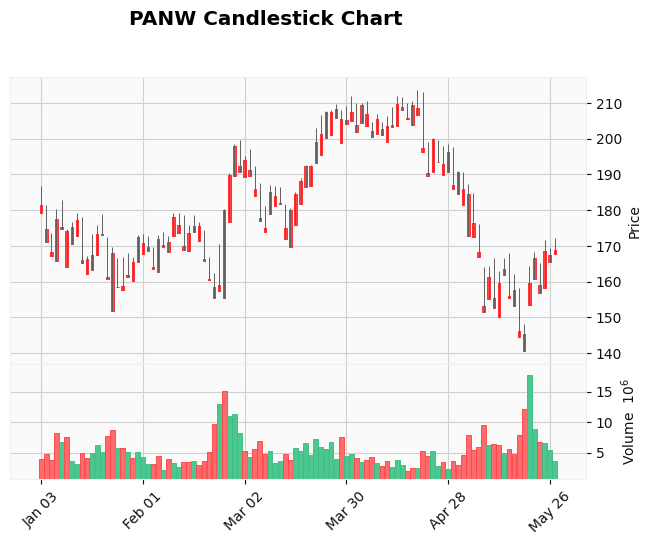

Empty DataFrame
Columns: [Date, Open, High, Low, Close, Doji, Hammer, HangingMan, BullishEngulfing]
Index: []


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import mplfinance as mpf
import yfinance as yf

# Define the stock and the date range
stock_symbol = 'PANW'
start_date = '2022-01-01'
end_date = '2022-05-30'

# Fetch stock data using yfinance
stock_data = yf.download(stock_symbol, start=start_date, end=end_date)

# Reset index and rename columns for mplfinance compatibility
stock_data.reset_index(inplace=True)
stock_data.columns = ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

# Plotting the candlestick chart
mpf.plot(stock_data.set_index('Date'), type='candle', volume=True, title='PANW Candlestick Chart', style='yahoo')

# Analyzing for candlestick patterns

# Function to identify Doji pattern
def is_doji(open, close, high, low):
    return abs(open - close) <= ((high - low) * 0.1)

# Function to identify Hammer pattern
def is_hammer(open, close, high, low):
    body = abs(close - open)
    lower_shadow = min(open, close) - low
    return (lower_shadow > body * 2) and (body < (high - low) * 0.3)

# Function to identify Hanging Man pattern
def is_hanging_man(open, close, high, low):
    body = abs(close - open)
    lower_shadow = min(open, close) - low
    return (lower_shadow > body * 2) and (body < (high - low) * 0.3)

# Function to identify Bullish Engulfing pattern
def is_bullish_engulfing(current_open, current_close, previous_open, previous_close):
    return (current_close > current_open) and \
           (previous_close < previous_open) and \
           (current_open < previous_close) and \
           (current_close > previous_open)

# Identify patterns in the DataFrame
stock_data['Doji'] = stock_data.apply(lambda row: is_doji(row['Open'], row['Close'], row['High'], row['Low']), axis=1)
stock_data['Hammer'] = stock_data.apply(lambda row: is_hammer(row['Open'], row['Close'], row['High'], row['Low']), axis=1)
stock_data['HangingMan'] = stock_data.apply(lambda row: is_hanging_man(row['Open'], row['Close'], row['High'], row['Low']), axis=1)

# Initialize Bullish Engulfing column
stock_data['BullishEngulfing'] = False

# Iterate through the data to identify Bullish Engulfing patterns
for i in range(1, len(stock_data)):
    stock_data.at[i, 'BullishEngulfing'] = is_bullish_engulfing(
        stock_data.at[i, 'Open'],
        stock_data.at[i, 'Close'],
        stock_data.at[i-1, 'Open'],
        stock_data.at[i-1, 'Close']
    )

# Print the identified patterns
identified_patterns = stock_data[(stock_data['Doji'] == True) | 
                                 (stock_data['Hammer'] == True) | 
                                 (stock_data['HangingMan'] == True) | 
                                 (stock_data['BullishEngulfing'] == True)]
print(identified_patterns[['Date', 'Open', 'High', 'Low', 'Close', 'Doji', 'Hammer', 'HangingMan', 'BullishEngulfing']])

